<div style="background:linear-gradient(135deg,#0a1230 0%,#141d44 55%,#1b1448 100%);border-radius:18px;padding:36px 32px;color:#fff;font-family:Inter,Segoe UI,sans-serif">
  <div style="font-size:12px;letter-spacing:3px;color:#00d4ff;font-weight:700;text-transform:uppercase">Part I · Foundations &nbsp;|&nbsp; Chapter 2</div>
  <div style="font-size:40px;font-weight:900;line-height:1.1;margin:10px 0 6px">Statistics, Data Science &amp; AI <span style="color:#00d4ff">🐍 Notebook</span></div>
  <div style="font-size:16px;color:#b9c2e0;max-width:700px;line-height:1.6">Five beginner-friendly demos showing how the three fields fit together — statistics makes sense of data, data science runs the whole pipeline, and machine learning / AI learns patterns to predict.</div>
  <div style="margin-top:18px;font-size:13px;color:#8892b0">Author: <b style="color:#e8eaf6">John Fisher</b> &nbsp;·&nbsp; Statistics, Data Science and AI: A Visual Handbook &nbsp;·&nbsp; 2026</div>
</div>

> ### 🎯 What you'll build in this notebook
>
> | # | Demo | Field it highlights |
> |---|------|---------------------|
> | 1 | Summarize daily app users | **Statistics** — make sense of data |
> | 2 | A mini data-science pipeline | **Data Science** — collect → clean → explore → visualize |
> | 3 | Learn from data to predict | **Machine Learning** — features, label, prediction |
> | 4 | Same data, two goals | **Statistics vs ML** — explain *why* vs predict *what* |
> | 5 | Getting smarter with more data | **AI** — improve as data grows |
> | 6 | A baby language model (next-word prediction) | **LLMs** — the statistics behind ChatGPT |

---

## ⚙️ Setup — imports & the book's plotting style
Same clean style as Chapter 1, so every chart in the handbook looks consistent.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

rng = np.random.default_rng(7)

# ---- Book palette ----
NAVY="#0a1230"; INK="#1a2138"; INK_SOFT="#4a5578"
CYAN="#0891b2"; PURPLE="#7c3aed"; AMBER="#d97706"
GREEN="#059669"; PINK="#db2777"; BLUE="#2563eb"
GRID="#e6e9f2"

plt.rcParams.update({
    "figure.facecolor":"white", "axes.facecolor":"white",
    "figure.dpi":110, "savefig.dpi":110, "font.size":11,
    "axes.edgecolor":GRID, "axes.linewidth":1.2,
    "axes.grid":True, "grid.color":GRID, "grid.linewidth":1, "axes.axisbelow":True,
    "axes.spines.top":False, "axes.spines.right":False,
    "axes.titlesize":15, "axes.titleweight":"bold", "axes.titlecolor":INK,
    "axes.labelcolor":INK_SOFT, "axes.labelsize":11.5,
    "xtick.color":INK_SOFT, "ytick.color":INK_SOFT, "legend.frameon":False,
})

def titlecard(ax, title, subtitle=None):
    ax.set_title(title, loc="left", pad=18)
    if subtitle:
        ax.text(0, 1.02, subtitle, transform=ax.transAxes, fontsize=10.5, color=INK_SOFT, va="bottom")

print("✅ Environment ready — palette loaded, RNG seeded.")

✅ Environment ready — palette loaded, RNG seeded.


<div style="background:#e0f7fb;border-left:5px solid #0891b2;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#0891b2;letter-spacing:1px">DEMO 1 · STATISTICS</span>
<div style="font-size:22px;font-weight:800;color:#1a2138;margin-top:4px">📊 Making sense of data</div>
<div style="color:#4a5578;margin-top:6px">Statistics takes a pile of raw numbers and answers <i>"what is going on here?"</i> — the typical value, and how spread out things are.</div>
</div>

In [2]:
# Daily active users of a small app over two weeks
users = pd.Series([120, 135, 150, 128, 142, 160, 158,
                   145, 139, 170, 165, 152, 148, 175], name="daily_users")

print(f"Mean (typical day): {users.mean():.0f} users")
print(f"Median            : {users.median():.0f} users")
print(f"Std deviation     : {users.std():.0f} users  (how much days vary)")
print(f"Min / Max         : {users.min()} / {users.max()}")

Mean (typical day): 149 users
Median            : 149 users
Std deviation     : 16 users  (how much days vary)
Min / Max         : 120 / 175


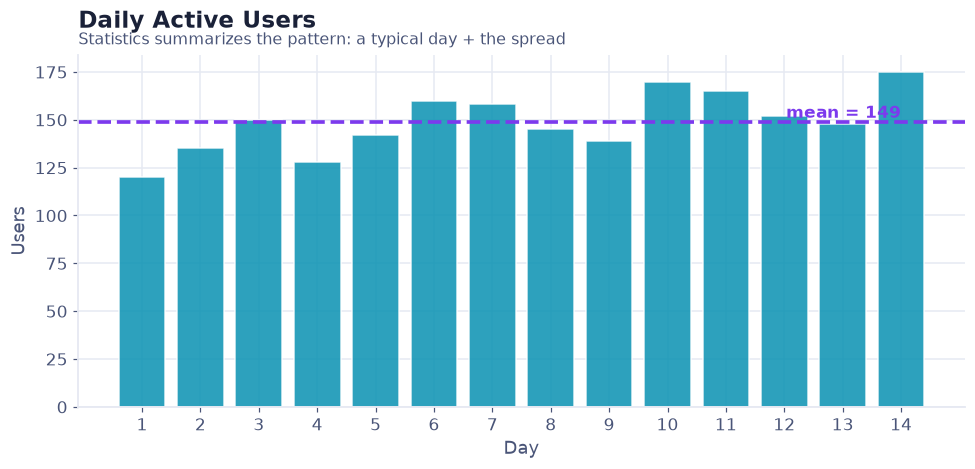

In [3]:
fig, ax = plt.subplots(figsize=(9,4.4))
days = np.arange(1, len(users)+1)
ax.bar(days, users, color=CYAN, alpha=0.85, edgecolor="white")
ax.axhline(users.mean(), color=PURPLE, ls="--", lw=2.4)
ax.text(len(users), users.mean()+2, f" mean = {users.mean():.0f}", color=PURPLE, fontweight="bold", ha="right")
titlecard(ax, "Daily Active Users", "Statistics summarizes the pattern: a typical day + the spread")
ax.set_xlabel("Day"); ax.set_ylabel("Users"); ax.set_xticks(days)
plt.tight_layout(); plt.show()

**Takeaway:** with two numbers — a center (mean ≈ 149) and a spread (std) — statistics turns 14 raw values into understanding.

<div style="background:#f0e9fe;border-left:5px solid #7c3aed;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#7c3aed;letter-spacing:1px">DEMO 2 · DATA SCIENCE</span>
<div style="font-size:22px;font-weight:800;color:#1a2138;margin-top:4px">🔍 The whole pipeline in miniature</div>
<div style="color:#4a5578;margin-top:6px">Data science is the end-to-end practice: <b>collect → clean → explore → communicate</b>. Here it is on a tiny sales table — including a real-world missing value.</div>
</div>

In [4]:
# 1) COLLECT — a small raw dataset (note the missing value, None)
data = pd.DataFrame({
    "store":  ["North","South","East","West","North","South","East","West"],
    "region": ["A","A","B","B","A","A","B","B"],
    "sales":  [220, 185, None, 240, 210, 195, 160, 250],
})
print("RAW data (notice the missing East sale):")
print(data)

RAW data (notice the missing East sale):
   store region  sales
0  North      A  220.0
1  South      A  185.0
2   East      B    NaN
3   West      B  240.0
4  North      A  210.0
5  South      A  195.0
6   East      B  160.0
7   West      B  250.0


In [5]:
# 2) CLEAN — fill the missing value with the column average
data["sales"] = data["sales"].fillna(round(data["sales"].mean(), 0))

# 3) EXPLORE — average sales per region
by_region = data.groupby("region")["sales"].mean()
print("Average sales by region:")
print(by_region)

Average sales by region:
region
A    202.50
B    214.75
Name: sales, dtype: float64


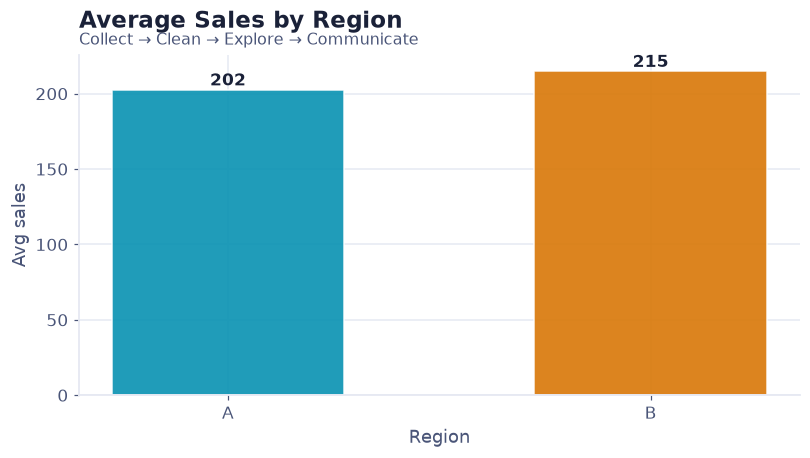

In [6]:
# 4) COMMUNICATE — a clear chart
fig, ax = plt.subplots(figsize=(7.5,4.3))
ax.bar(by_region.index, by_region.values, color=[CYAN, AMBER], alpha=0.9, edgecolor="white", width=0.55)
for i, v in enumerate(by_region.values):
    ax.text(i, v+3, f"{v:.0f}", ha="center", fontweight="bold", color=INK)
titlecard(ax, "Average Sales by Region", "Collect → Clean → Explore → Communicate")
ax.set_xlabel("Region"); ax.set_ylabel("Avg sales")
plt.tight_layout(); plt.show()

**Takeaway:** data science strings the steps together — and statistics shows up *inside* it (the average we used to clean and to compare regions).

<div style="background:#fef3e2;border-left:5px solid #d97706;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#d97706;letter-spacing:1px">DEMO 3 · MACHINE LEARNING</span>
<div style="font-size:22px;font-weight:800;color:#1a2138;margin-top:4px">🤖 Learning from data to predict</div>
<div style="color:#4a5578;margin-top:6px">Machine learning finds a pattern in past data, then predicts for new cases. The inputs are <b>features</b>; the thing we predict is the <b>label</b>.</div>
</div>

In [7]:
# FEATURE: hours studied   ->   LABEL: exam score
hours  = np.array([1, 2, 3, 4, 5, 6, 7, 8])           # feature (input)
scores = np.array([52, 58, 61, 70, 72, 80, 85, 91])   # label   (what we predict)

# "Train" a simple model = fit the best straight line (least squares)
slope, intercept = np.polyfit(hours, scores, 1)

# PREDICT for a new student who studied 5.5 hours
new_hours = 5.5
predicted = slope*new_hours + intercept
print(f"Learned pattern : score = {intercept:.1f} + {slope:.1f} * hours")
print(f"Prediction      : a student studying {new_hours} hrs -> about {predicted:.0f} points")

Learned pattern : score = 46.1 + 5.6 * hours
Prediction      : a student studying 5.5 hrs -> about 77 points


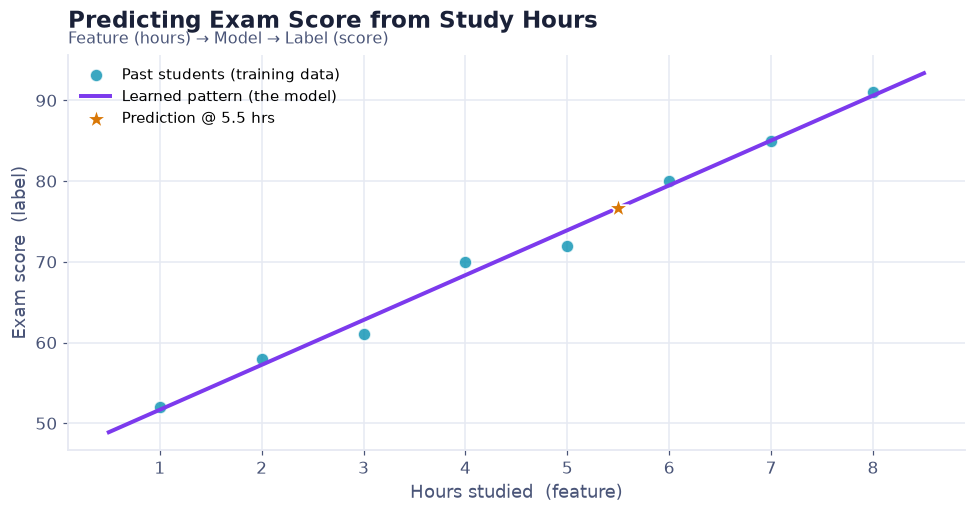

In [8]:
fig, ax = plt.subplots(figsize=(9,4.8))
ax.scatter(hours, scores, color=CYAN, s=70, alpha=0.8, edgecolor="white", linewidth=1, label="Past students (training data)")
xs = np.linspace(0.5, 8.5, 100)
ax.plot(xs, slope*xs+intercept, color=PURPLE, lw=2.6, label="Learned pattern (the model)")
ax.scatter([new_hours],[predicted], color=AMBER, s=200, marker="*", zorder=5, edgecolor="white", linewidth=1.2, label=f"Prediction @ {new_hours} hrs")
titlecard(ax, "Predicting Exam Score from Study Hours", "Feature (hours) → Model → Label (score)")
ax.set_xlabel("Hours studied  (feature)"); ax.set_ylabel("Exam score  (label)")
ax.legend(loc="upper left", fontsize=9.5)
plt.tight_layout(); plt.show()

**Takeaway:** the "learning" is just fitting a pattern to past data — a statistical idea (regression) doing the work behind the ML label.

<div style="background:#e3f6ee;border-left:5px solid #059669;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#059669;letter-spacing:1px">DEMO 4 · STATISTICS vs MACHINE LEARNING</span>
<div style="font-size:22px;font-weight:800;color:#1a2138;margin-top:4px">⚖️ Same data, two different goals</div>
<div style="color:#4a5578;margin-top:6px">Statistics usually asks <b>"why / how strong is the relationship?"</b> (explain). Machine learning usually asks <b>"what will happen next?"</b> (predict). Same numbers — different questions.</div>
</div>

In [9]:
# Reuse the study-hours data from Demo 3
# STATISTICS goal -> EXPLAIN: how strongly are hours & scores related?
corr = np.corrcoef(hours, scores)[0,1]
print("STATISTICS (explain):")
print(f"  Correlation between hours and score = {corr:.2f}  (very strong, positive)")
print(f"  Interpretation: more study hours are strongly associated with higher scores.\n")

# MACHINE LEARNING goal -> PREDICT: scores for brand-new students
new_students = np.array([2.5, 4.5, 7.5])
preds = slope*new_students + intercept
print("MACHINE LEARNING (predict):")
for h, p in zip(new_students, preds):
    print(f"  A student studying {h} hrs -> predicted score {p:.0f}")

STATISTICS (explain):
  Correlation between hours and score = 1.00  (very strong, positive)
  Interpretation: more study hours are strongly associated with higher scores.

MACHINE LEARNING (predict):
  A student studying 2.5 hrs -> predicted score 60
  A student studying 4.5 hrs -> predicted score 71
  A student studying 7.5 hrs -> predicted score 88


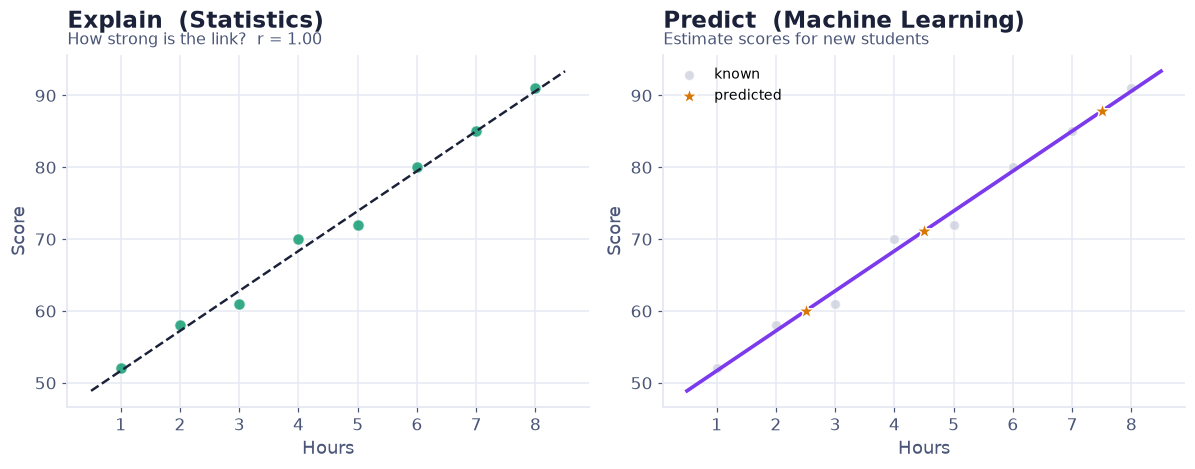

In [10]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11,4.4))

# Left: explain (relationship strength)
a1.scatter(hours, scores, color=GREEN, s=60, alpha=0.8, edgecolor="white")
a1.plot(xs, slope*xs+intercept, color=INK, lw=1.6, ls="--")
titlecard(a1, "Explain  (Statistics)", f"How strong is the link?  r = {corr:.2f}")
a1.set_xlabel("Hours"); a1.set_ylabel("Score")

# Right: predict (new points)
a2.scatter(hours, scores, color="#c7c9d9", s=45, alpha=0.7, edgecolor="white", label="known")
a2.plot(xs, slope*xs+intercept, color=PURPLE, lw=2.4)
a2.scatter(new_students, preds, color=AMBER, s=130, marker="*", zorder=5, edgecolor="white", label="predicted")
titlecard(a2, "Predict  (Machine Learning)", "Estimate scores for new students")
a2.set_xlabel("Hours"); a2.set_ylabel("Score"); a2.legend(fontsize=9)
plt.tight_layout(); plt.show()

**Takeaway:** they are partners, not rivals. Statistics tells you *whether and why* a pattern is real; ML uses that pattern to *predict at scale*.

<div style="background:#e6effe;border-left:5px solid #2563eb;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#2563eb;letter-spacing:1px">DEMO 5 · ARTIFICIAL INTELLIGENCE</span>
<div style="font-size:22px;font-weight:800;color:#1a2138;margin-top:4px">🚀 Getting smarter with more data</div>
<div style="color:#4a5578;margin-top:6px">A core idea of AI: the more (good) data a system sees, the better its estimates get. Here a model learns the true "click rate" of an ad, and homes in as data grows.</div>
</div>

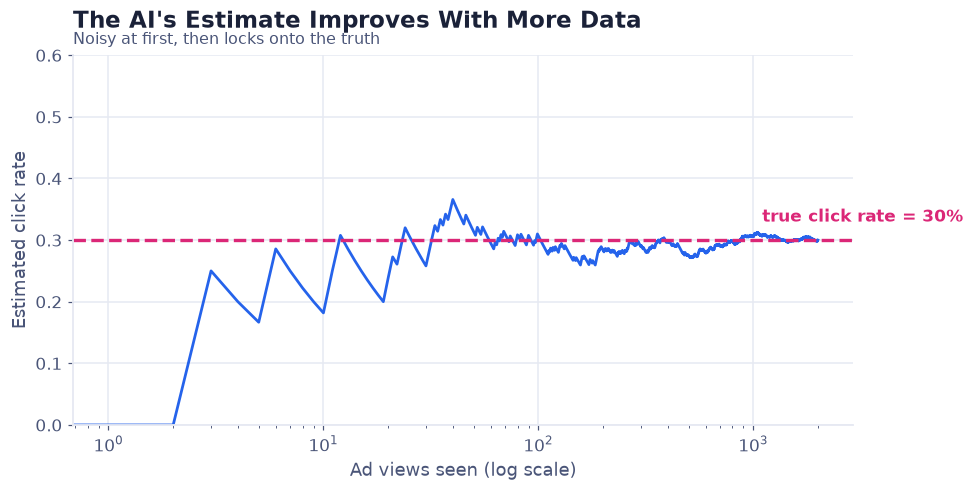

After   10 views -> estimate = 20.0%
After  100 views -> estimate = 31.0%
After 2000 views -> estimate = 30.0%


In [11]:
TRUE_RATE = 0.30                      # the real click-through rate the AI is trying to learn
clicks = rng.random(2000) < TRUE_RATE # simulate 2000 ad views (True = clicked)
estimate = np.cumsum(clicks) / np.arange(1, len(clicks)+1)

fig, ax = plt.subplots(figsize=(9,4.6))
ax.plot(estimate, color=BLUE, lw=1.8)
ax.axhline(TRUE_RATE, color=PINK, ls="--", lw=2.2)
ax.text(len(clicks)*0.55, TRUE_RATE+0.03, "true click rate = 30%", color=PINK, fontweight="bold")
ax.set_xscale("log")
titlecard(ax, "The AI's Estimate Improves With More Data", "Noisy at first, then locks onto the truth")
ax.set_xlabel("Ad views seen (log scale)"); ax.set_ylabel("Estimated click rate")
ax.set_ylim(0, 0.6)
plt.tight_layout(); plt.show()

for n in [10, 100, 2000]:
    print(f"After {n:>4} views -> estimate = {estimate[n-1]*100:.1f}%")

**Takeaway:** "learning" and "continuous improvement" in AI are powered by statistics — more data shrinks uncertainty and sharpens every prediction.

<div style="background:linear-gradient(135deg,#1e1b4b,#4338ca);border-radius:12px;padding:18px 22px;color:#fff;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#a5b4fc;letter-spacing:1px">DEMO 6 · LARGE LANGUAGE MODELS</span>
<div style="font-size:22px;font-weight:800;margin-top:4px">💬 A baby language model (the statistics behind ChatGPT)</div>
<div style="color:#c7d2fe;margin-top:6px">LLMs predict the <i>next word</i> from probabilities learned from huge amounts of text. Let's build a tiny version and watch the statistics at work.</div>
</div>

In [12]:
from collections import defaultdict, Counter

# A tiny "training corpus" (real LLMs train on trillions of words)
corpus = ("the cat sat on the mat . the cat saw the dog . "
          "the dog sat on the rug . the cat sat on the sofa .")
words = corpus.split()

# Count which word tends to follow each word (a simple "bigram" model)
nxt = defaultdict(Counter)
for a, b in zip(words[:-1], words[1:]):
    nxt[a][b] += 1

# What tends to follow the word "the"?
ctx = "the"
counts = nxt[ctx]
total = sum(counts.values())
probs = {w: c/total for w, c in counts.most_common()}
print(f'Learned probabilities  P(next word | "{ctx}"):')
for w, p in probs.items():
    print(f"   {w:<5} {p:5.0%}")

Learned probabilities  P(next word | "the"):
   cat     38%
   dog     25%
   mat     12%
   rug     12%
   sofa    12%


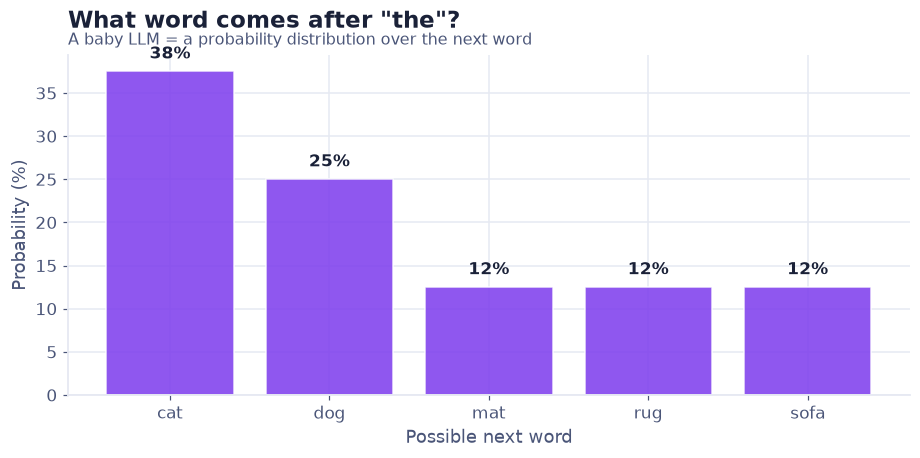

In [13]:
# Visualize the probability distribution over the next word
fig, ax = plt.subplots(figsize=(8.5,4.3))
ws = list(probs.keys()); ps = [probs[w]*100 for w in ws]
bars = ax.bar(ws, ps, color=PURPLE, alpha=0.85, edgecolor="white")
for b, p in zip(bars, ps):
    ax.text(b.get_x()+b.get_width()/2, p+1.5, f"{p:.0f}%", ha="center", fontweight="bold", color=INK)
titlecard(ax, 'What word comes after "the"?', "A baby LLM = a probability distribution over the next word")
ax.set_ylabel("Probability (%)"); ax.set_xlabel("Possible next word")
plt.tight_layout(); plt.show()

In [14]:
# "Generate" text by repeatedly sampling the next word from these probabilities
def sample_next(w):
    options, weights = zip(*nxt[w].items())
    weights = np.array(weights, dtype=float); weights /= weights.sum()
    return rng.choice(options, p=weights)

word = "the"; sentence = [word]
for _ in range(9):
    if not nxt[word]:
        break
    word = sample_next(word); sentence.append(word)
print("Generated text:", " ".join(sentence))

Generated text: the cat sat on the dog sat on the cat


**Takeaway:** that's the whole trick — predict the next word from learned probabilities, then repeat. Real LLMs use billions of parameters and trillions of words, but the engine is statistical: a probability model of language. The same ideas from Chapter 1 (probability, learning parameters from data) are what power ChatGPT.

---
<div style="background:#ffffff;border:1px solid #e6e9f2;border-radius:16px;padding:24px 28px;font-family:Inter,sans-serif;box-shadow:0 8px 30px rgba(20,30,80,0.05)">
<div style="font-size:20px;font-weight:800;color:#1a2138">🎓 Recap</div>
<ul style="color:#4a5578;line-height:1.9;margin-top:10px">
<li><b>Statistics</b> makes sense of data — center &amp; spread turn numbers into understanding.</li>
<li><b>Data science</b> runs the full pipeline: collect → clean → explore → communicate.</li>
<li><b>Machine learning</b> learns a pattern (features → label) to predict new cases.</li>
<li><b>Explain vs predict</b>: statistics asks <i>why</i>, ML asks <i>what next</i> — partners on the same data.</li>
<li><b>AI</b> improves with more data because statistics shrinks uncertainty as evidence grows.</li>
<li><b>LLMs</b> (ChatGPT &amp; friends) predict the next word from learned probabilities — statistics at massive scale.</li>
</ul>
</div>

<div style="text-align:center;color:#8b94b3;font-size:12px;margin-top:18px">Statistics, Data Science and AI: A Visual Handbook · © 2026 John Fisher</div>